In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
VOCAB = pd.read_csv("VOCAB.csv", sep="|", index_col="term_str")
BOW = pd.read_csv("BOW.csv", sep="|")
LIB = pd.read_csv("LIB.csv", sep="|", index_col=0)

# Sentiment VOCAB_SENT (4)

In [13]:

# Load NRC lexicon 
SALEX = pd.read_csv('salex_nrc.csv').set_index('term_str')
SALEX.columns = [col.replace('nrc_', '') for col in SALEX.columns]

emo_cols = "anger anticipation disgust fear joy sadness surprise trust sentiment".split()

# Join VOCAB with sentiment lexicon
VOCAB_SENT = VOCAB.join(SALEX, how='inner')
VOCAB_SENT = VOCAB_SENT[emo_cols]
VOCAB_SENT

VOCAB_SENT.to_csv('/Users/natalieseah/Desktop/TextasData/VOCAB_SENT.csv', sep='|')

# Sentiment BOW_SENT (4)

In [10]:
# Map sentiment values onto BOW
BOW_SENT = BOW.join(VOCAB_SENT, on='term_str', how='left')
BOW_SENT = BOW_SENT.dropna(subset=emo_cols).copy()

# Weight each sentiment column by token count
for col in emo_cols:
    BOW_SENT[col + '_w'] = BOW_SENT[col] * BOW_SENT['n']

BOW_SENT

BOW_SENT.to_csv('/Users/natalieseah/Desktop/TextasData/BOW_SENT.csv', sep='|')

# Sentiment DOC_SENT (4)

In [11]:
# Sum weighted sentiment per song
DOC_SENT_NUM = BOW_SENT.groupby('song_id')[[col + '_w' for col in emo_cols]].sum()

# Sum total matched tokens per song
DOC_SENT_DEN = BOW_SENT.groupby('song_id')['n'].sum()

# Divide weighted sums by total token counts
DOC_SENT = DOC_SENT_NUM.div(DOC_SENT_DEN, axis=0)
DOC_SENT.columns = emo_cols

# Add metadata back
DOC_SENT = DOC_SENT.join(LIB[['Artist', 'Year']])

DOC_SENT

DOC_SENT.to_csv('/Users/natalieseah/Desktop/TextasData/DOC_SENT.csv', sep='|')

# Sentiment Plot (4)

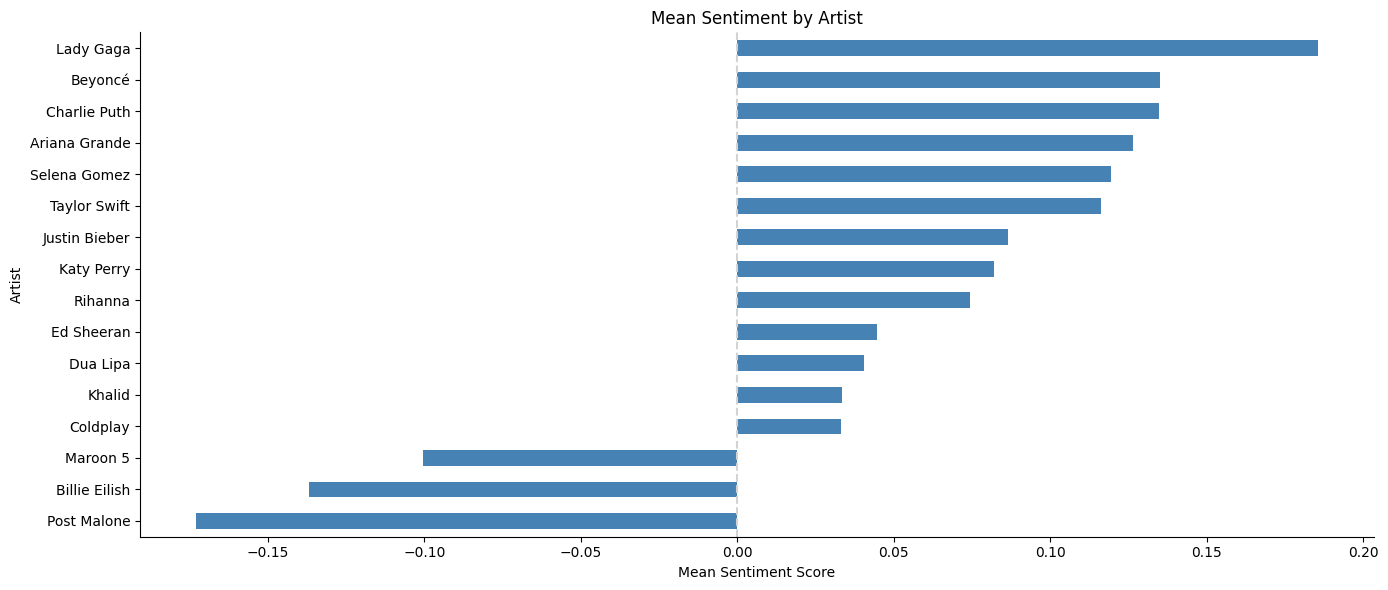

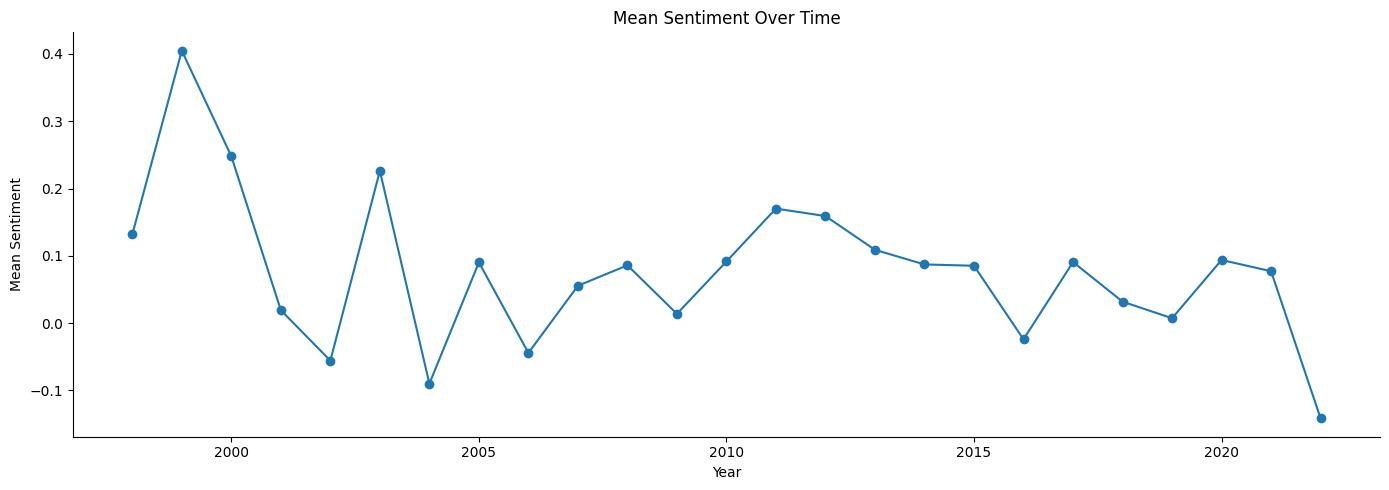

In [12]:
# Mean sentiment per artist
ARTIST_SENT = DOC_SENT.groupby('Artist')[emo_cols].mean()

# Bar chart of sentiment by artist
fig, ax = plt.subplots(figsize=(14, 6))
ARTIST_SENT['sentiment'].sort_values().plot.barh(ax=ax, color='steelblue')
ax.axvline(0, color='lightgray', ls='--')
ax.set_xlabel('Mean Sentiment Score')
ax.set_title('Mean Sentiment by Artist')
sns.despine()
plt.tight_layout()
plt.show()

# Alternatively, plot sentiment over year
YEAR_SENT = DOC_SENT.groupby('Year')['sentiment'].mean()
YEAR_SENT = YEAR_SENT[YEAR_SENT.index > 1900] 

fig, ax = plt.subplots(figsize=(14, 5))
YEAR_SENT.plot(ax=ax, marker='o')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Sentiment')
ax.set_title('Mean Sentiment Over Time')
sns.despine()
plt.tight_layout()
plt.show()